In [1]:
import pandas as pd
import re
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib as mpl

from utils import collect_metrics
from utils import DISEASE_COLS, SYMPTOM_COLS, OUTPUT_FORMAT

sns.set_theme(style="ticks")

def search_alpha(x):
    match = re.search(r"\[alpha=([0-9\.]+)\]", x)
    alpha = 0 if match is None else float(match.group(1))
    return alpha

def search_beta(x):
    match = re.search(r"\[beta=([0-9\.]+)\]", x)
    beta = 0 if match is None else float(match.group(1))
    return beta

def search_gamma(x):
    match = re.search(r"\[gamma=([0-9\.]+)\]", x)
    beta = 0 if match is None else float(match.group(1))
    return beta

def get_model(x):
    base = x.split("_")[-1]
    return base

def get_base_model(x):
    base = x.split("_")[-1]
    base = base.split("]")[-1]
    return base

def get_kind(path, x):
    if "CLIP" in path:
        return "CLIP"
    if "gamma" in path and search_gamma(path)>0:
        return "S2D-MTL-Matrix"
    
    return "BASE" if "]" not in x else x.split("]")[0][1:]


In [2]:

df_sym = collect_metrics("sym")
print("Updated metrics in performance_sym.csv")

df_dis = collect_metrics("dis")
print("Updated metrics in performance_dis.csv")


Processing 0 new files
Updated metrics in performance_sym.csv
Processing 0 new files
Updated metrics in performance_dis.csv


In [3]:
df_s = pd.read_csv("performance_sym.csv")
df_d = pd.read_csv("performance_dis.csv")

for df in [df_s, df_d]:
    df.path = df.path.str.replace("runs/","")
    df["alpha"] = df.path.apply(lambda x: search_alpha(x))
    df["beta"] = df.path.apply(lambda x: search_beta(x))
    df["gamma"] = df.path.apply(lambda x: search_gamma(x))
    df["backbone"] = df.path.apply(lambda x: get_base_model(x))
    df["model"] = df.path.apply(lambda x: get_model(x))
    df["kind"] = df.apply(lambda x: get_kind(x.path, x.model), axis=1)
    df["target"] = df.path.apply(lambda x: "sym" if "_sym_" in x else "dis")
    df["params"] = df.apply(lambda row: (row.alpha, row.beta, row.gamma), axis=1)


In [4]:
print(df_s.kind.value_counts())
print()
print(df_d.kind.value_counts())

kind
S2D-MTL           23
MTL               21
BASE               5
S2D-MTL-Matrix     5
CLIP               4
Name: count, dtype: int64

kind
S2D-MTL           23
MTL               21
S2D-MTL-Matrix     5
BASE               5
CLIP               4
Name: count, dtype: int64


In [5]:
def calc_table(df_d, df_s, best_metric, which):

    all_results = []

    s_kinds = df_s.kind.unique()
    d_kinds = df_d.kind.unique()

    # ===================================================
    if "CLIP" in s_kinds or "CLIP" in d_kinds:
    
        query_clip = "kind == 'CLIP'"
        dis = df_d.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","wF1","sF1","AUC"]].set_index("model")
        sym = df_s.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","wF1","sF1","AUC"]].set_index("model")
        dis.columns = ["DIS path", "DIS wF1", "DIS sF1", "DIS AUC"]
        sym.columns = ["SYM path", "SYM wF1", "SYM sF1", "SYM AUC"]
        tmp = pd.concat((dis,sym), axis=1).reset_index()
        tmp["kind"] = "CLIP"
        all_results.append(tmp)
    
    # ===================================================
    if "BASE" in s_kinds or "BASE" in d_kinds:
    
        query_clip = "kind == 'BASE'"
        dis = df_d.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","wF1","sF1","AUC"]].set_index("model")
        sym = df_s.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","wF1","sF1","AUC"]].set_index("model")
        dis.columns = ["DIS path", "DIS wF1", "DIS sF1", "DIS AUC"]
        sym.columns = ["SYM path", "SYM wF1", "SYM sF1", "SYM AUC"]
        tmp = pd.concat((dis,sym), axis=1).reset_index()
        tmp["kind"] = "VISION"
        all_results.append(tmp)
    
    # ===================================================
    if "MTL" in s_kinds or "MTL" in d_kinds:
    
        query_clip = "kind == 'MTL'"
        dis = df_d.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","params","backbone","wF1","sF1","AUC"]].set_index("model")
        sym = df_s.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","params","backbone","wF1","sF1","AUC"]].set_index("model")
        sym.columns = ["_"+c for c in sym.columns]
        
        dis_sym = pd.concat((dis,sym), axis=1)
        dis_sym.wF1 = dis_sym.wF1 + dis_sym._wF1 if which=="both" else (dis_sym.wF1 if which=="dis" else dis_sym._wF1)
        dis_sym.sF1 = dis_sym.sF1 + dis_sym._sF1 if which=="both" else (dis_sym.sF1 if which=="dis" else dis_sym._sF1)
        dis_sym.AUC = dis_sym.AUC + dis_sym._AUC if which=="both" else (dis_sym.AUC if which=="dis" else dis_sym._AUC)
        dis_sym.drop(columns = sym.columns, inplace=True)
        
        sym.columns = dis.columns
        
        rows = []
        for _, data in dis_sym.groupby("backbone"):
            row = data.sort_values(best_metric, ascending=False).iloc[0]
            rows.append(row)
        dis_sym = pd.concat(rows, axis=1).T
        
        dis = dis.loc[dis_sym.index].set_index("backbone")
        sym = sym.loc[dis_sym.index].set_index("backbone")
        
        dis.columns = ["DIS path", "DIS params", "DIS wF1", "DIS sF1", "DIS AUC"]
        sym.columns = ["SYM path", "SYM params", "SYM wF1", "SYM sF1", "SYM AUC"]
        tmp = pd.concat((dis,sym), axis=1).reset_index().rename(columns={"backbone":"model"}).sort_values("model", ascending=False)
        tmp["kind"] = "MTL"
        
        all_results.append(tmp)
    
    # ===================================================
    if "S2D-MTL" in s_kinds or "S2D-MTL" in d_kinds:
    
        query_clip = "kind == 'S2D-MTL'"
        dis = df_d.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","params","backbone","wF1","sF1","AUC"]].set_index("model")
        sym = df_s.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","params","backbone","wF1","sF1","AUC"]].set_index("model")
        sym.columns = ["_"+c for c in sym.columns]
        
        dis_sym = pd.concat((dis,sym), axis=1)
        dis_sym.wF1 = dis_sym.wF1 + dis_sym._wF1 if which=="both" else (dis_sym.wF1 if which=="dis" else dis_sym._wF1)
        dis_sym.sF1 = dis_sym.sF1 + dis_sym._sF1 if which=="both" else (dis_sym.sF1 if which=="dis" else dis_sym._sF1)
        dis_sym.AUC = dis_sym.AUC + dis_sym._AUC if which=="both" else (dis_sym.AUC if which=="dis" else dis_sym._AUC)
        dis_sym.drop(columns = sym.columns, inplace=True)
        
        sym.columns = dis.columns
        
        rows = []
        for _, data in dis_sym.groupby("backbone"):
            row = data.sort_values(best_metric, ascending=False).iloc[0]
            rows.append(row)
        dis_sym = pd.concat(rows, axis=1).T
        
        dis = dis.loc[dis_sym.index].set_index("backbone")
        sym = sym.loc[dis_sym.index].set_index("backbone")
        
        dis.columns = ["DIS path", "DIS params", "DIS wF1", "DIS sF1", "DIS AUC"]
        sym.columns = ["SYM path", "SYM params", "SYM wF1", "SYM sF1", "SYM AUC"]
        tmp = pd.concat((dis,sym), axis=1).reset_index().rename(columns={"backbone":"model"}).sort_values("model", ascending=False)
        tmp["kind"] = "S2D-MTL"
        
        all_results.append(tmp)
    
    # ===================================================
    if "S2D-MTL-Matrix" in s_kinds or "S2D-MTL-Matrix" in d_kinds:
    
        query_clip = "kind == 'S2D-MTL-Matrix'"
        dis = df_d.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","params","backbone","wF1","sF1","AUC"]].set_index("model")
        sym = df_s.query(query_clip).sort_values(["backbone","model"], ascending=False)[["path","model","params","backbone","wF1","sF1","AUC"]].set_index("model")
        sym.columns = ["_"+c for c in sym.columns]
        
        dis_sym = pd.concat((dis,sym), axis=1)
        dis_sym.wF1 = dis_sym.wF1 + dis_sym._wF1 if which=="both" else (dis_sym.wF1 if which=="dis" else dis_sym._wF1)
        dis_sym.sF1 = dis_sym.sF1 + dis_sym._sF1 if which=="both" else (dis_sym.sF1 if which=="dis" else dis_sym._sF1)
        dis_sym.AUC = dis_sym.AUC + dis_sym._AUC if which=="both" else (dis_sym.AUC if which=="dis" else dis_sym._AUC)
        dis_sym.drop(columns = sym.columns, inplace=True)
        
        sym.columns = dis.columns
        
        rows = []
        for _, data in dis_sym.groupby("backbone"):
            row = data.sort_values(best_metric, ascending=False).iloc[0]
            rows.append(row)
        dis_sym = pd.concat(rows, axis=1).T
        
        dis = dis.loc[dis_sym.index].set_index("backbone")
        sym = sym.loc[dis_sym.index].set_index("backbone")
        
        dis.columns = ["DIS path", "DIS params", "DIS wF1", "DIS sF1", "DIS AUC"]
        sym.columns = ["SYM path", "SYM params", "SYM wF1", "SYM sF1", "SYM AUC"]
        tmp = pd.concat((dis,sym), axis=1).reset_index().rename(columns={"backbone":"model"}).sort_values("model", ascending=False)
        tmp["kind"] = "S2D-MTL-Matrix"
        
        all_results.append(tmp)
    
    # ===================================================
    
    all_results = pd.concat(all_results).reset_index(drop=True)
    float_cols = ["DIS wF1", "DIS sF1", "DIS AUC", "SYM wF1", "SYM sF1", "SYM AUC"]
    display(all_results.drop(columns=["DIS path", "SYM path"]).style.background_gradient(cmap='Blues', subset=float_cols))
    return all_results

In [6]:
best_metric = "wF1"
which = "sym"
which = "dis"
which = "both"

# _=calc_table(df_d, df_s, "wF1", "both")
# _=calc_table(df_d, df_s, "wF1", "sym")
res=calc_table(df_d, df_s, "wF1", "dis")

print()
print(res.set_index(["kind", "model"]).drop(columns=["SYM params", "DIS path", "SYM path"]).to_latex(float_format="%.4f", index=True, bold_rows=False))
print()
print(res.set_index(["kind", "model"]).drop(columns=["SYM params", "DIS path", "SYM path"]).to_markdown())

,model,DIS wF1,DIS sF1,DIS AUC,SYM wF1,SYM sF1,SYM AUC,kind,DIS params,SYM params
0,vit.h.laion2b,0.681453,0.514588,0.550998,0.263346,0.262964,0.613133,CLIP,nan,nan
1,vit.base.32,0.752777,0.515231,0.497007,0.362596,0.335202,0.617626,CLIP,nan,nan
2,bioclip2,0.761171,0.510015,0.426648,0.629729,0.481830,0.563277,CLIP,nan,nan
3,bioclip,0.222600,0.264550,0.363404,0.221865,0.231154,0.382788,CLIP,nan,nan
4,swint,0.904690,0.893122,0.951301,0.664684,0.699338,0.781854,VISION,nan,nan
5,resnet,0.883583,0.895238,0.946797,0.680997,0.715236,0.765617,VISION,nan,nan
6,mobilenet,0.818458,0.831217,0.913028,0.667178,0.721114,0.811542,VISION,nan,nan
7,efficientnet,0.914453,0.931217,0.935865,0.618640,0.695175,0.784536,VISION,nan,nan
8,convnext,0.897531,0.906349,0.953968,0.690539,0.709958,0.791034,VISION,nan,nan
9,swint,0.934629,0.937566,0.956119,0.635138,0.710317,0.802434,MTL,"(0.6, 0.0, 0.0)","(0.6, 0.0, 0.0)"



\begin{tabular}{llrrrrrrl}
\toprule
 &  & DIS wF1 & DIS sF1 & DIS AUC & SYM wF1 & SYM sF1 & SYM AUC & DIS params \\
kind & model &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{CLIP} & vit.h.laion2b & 0.6815 & 0.5146 & 0.5510 & 0.2633 & 0.2630 & 0.6131 & NaN \\
 & vit.base.32 & 0.7528 & 0.5152 & 0.4970 & 0.3626 & 0.3352 & 0.6176 & NaN \\
 & bioclip2 & 0.7612 & 0.5100 & 0.4266 & 0.6297 & 0.4818 & 0.5633 & NaN \\
 & bioclip & 0.2226 & 0.2646 & 0.3634 & 0.2219 & 0.2312 & 0.3828 & NaN \\
\cline{1-9}
\multirow[t]{5}{*}{VISION} & swint & 0.9047 & 0.8931 & 0.9513 & 0.6647 & 0.6993 & 0.7819 & NaN \\
 & resnet & 0.8836 & 0.8952 & 0.9468 & 0.6810 & 0.7152 & 0.7656 & NaN \\
 & mobilenet & 0.8185 & 0.8312 & 0.9130 & 0.6672 & 0.7211 & 0.8115 & NaN \\
 & efficientnet & 0.9145 & 0.9312 & 0.9359 & 0.6186 & 0.6952 & 0.7845 & NaN \\
 & convnext & 0.8975 & 0.9063 & 0.9540 & 0.6905 & 0.7100 & 0.7910 & NaN \\
\cline{1-9}
\multirow[t]{5}{*}{MTL} & swint & 0.9346 & 0.9376 & 0.9561 & 0.6351 & 0.7103 & 0.

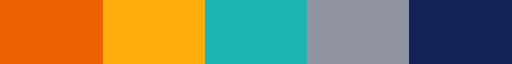

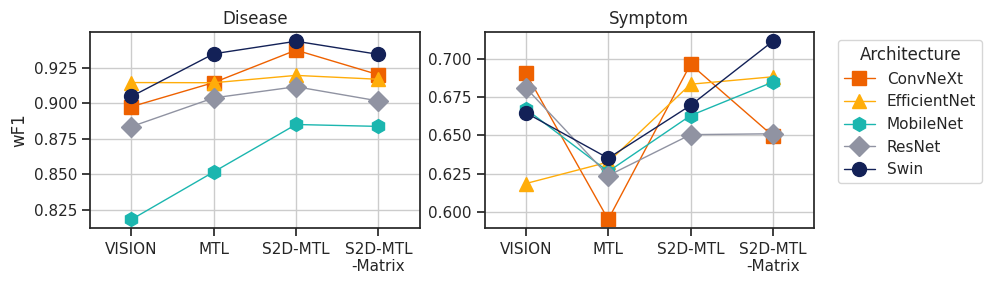

In [7]:
EdvardMunch_1 = ["#272A2AFF", "#E69253FF", "#EDB931FF", "#E4502EFF", "#4378A0FF"]
Apricot = ["#EE6100FF", "#FFAD0AFF", "#1BB6AFFF", "#9093A2FF", "#132157FF"]
Badlands = ["#5495CFFF", "#F5AF4DFF", "#DB4743FF", "#7C873EFF", "#132157FF"]
CafeTerrace = ["#024873FF", "#A2A637FF", "#D9AA1EFF", "#D98825FF", "#BF4F26FF"]
name2marker = {
    "convnext":     "s",
    "efficientnet": "^",
    "mobilenet":    "h",
    "resnet":       "D",
    "swint":        "o",
}
name2paper = {
    "convnext": "ConvNeXt",
    "efficientnet": "EfficientNet",
    "mobilenet": "MobileNet",
    "resnet": "ResNet",
    "swint": "Swin",
}
cmap = mpl.colors.ListedColormap(Apricot)

display(cmap)
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(10,3))

tmp = res.pivot(columns=["model"], values="DIS wF1", index="kind").drop(index=["CLIP"]).dropna(axis=1).loc[["VISION", "MTL", "S2D-MTL", "S2D-MTL-Matrix"]].T.rename(columns={"S2D-MTL-Matrix": "S2D-MTL\n-Matrix"})#.plot(ax=axs[0], marker="o", lw=1, ls="-", ms=10, cmap=cmap, rot=0, legend=False)
for idx, (mname, row) in enumerate(tmp.iterrows()):
    axs[0].plot(row, ls="-", lw=1, marker=name2marker[mname], ms=10, color=cmap(idx), label=name2paper[mname])

tmp = res.pivot(columns=["model"], values="SYM wF1", index="kind").drop(index=["CLIP"]).dropna(axis=1).loc[["VISION", "MTL", "S2D-MTL", "S2D-MTL-Matrix"]].T.rename(columns={"S2D-MTL-Matrix": "S2D-MTL\n-Matrix"})#.plot(ax=axs[1], marker="o", lw=1, ls="-", ms=10, cmap=cmap, rot=0, legend="reverse")
for idx, (mname, row) in enumerate(tmp.iterrows()):
    axs[1].plot(row, ls="-", lw=1, marker=name2marker[mname], ms=10, color=cmap(idx), label=name2paper[mname])
axs[1].legend(bbox_to_anchor=(1.05, 1), title="Architecture")
for ax in axs:
    # ax.grid(False)
    # ax.xaxis.grid(True)
    ax.set_xticks([0,1,2,3])
    ax.set_xlim([-0.5,3.5])
    ax.set_xlabel("")
    ax.grid(True)
axs[0].set_ylabel("wF1")
axs[0].set_title("Disease")
axs[1].set_title("Symptom")
plt.tight_layout()
plt.savefig(f"fig/fig_dis_sym_results.{OUTPUT_FORMAT}")

convnext
resnet


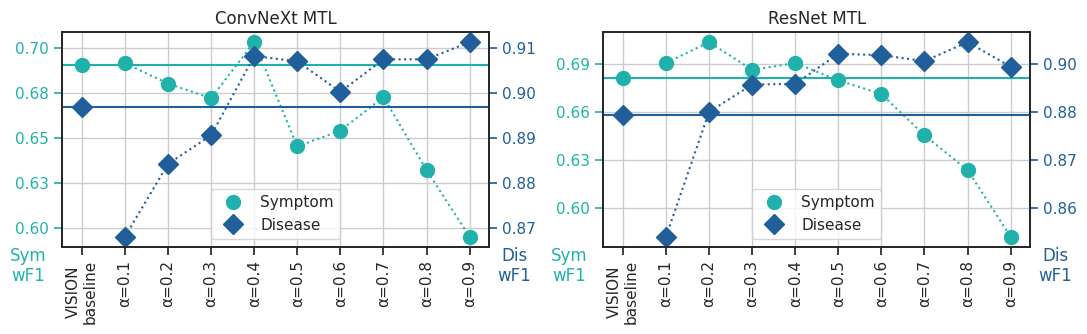

In [8]:
gb = df_s.groupby("backbone")
gb_d = df_d.groupby("backbone")

DIS_COL = "#215f9a"
SYM_COL = "LightSeaGreen"

fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(11,3.5))
idx = -1
for model, group in gb:

    group_d = gb_d.get_group(model)

    if model not in ["resnet", "convnext"]:
        continue
    idx+=1
    print(model)
    
    METRIC = "wF1"
    
    # fig, ax = plt.subplots(1,1,figsize=(8,4))
    ax = axs[idx]
    ax2 = ax.twinx()
    
    baseline = group[(group.kind=="BASE")]
    baseline_points = baseline[METRIC].tolist()
    baseline_x = [0]
    baseline_txt = ["VISION\nbaseline"]
    ax.plot(baseline_x, baseline_points, "o:", ms=10, color=SYM_COL)

    ax.axhline(baseline_points, color=SYM_COL)

    baseline = group_d[(group_d.kind=="BASE")]
    baseline_points = baseline[METRIC].tolist()
    baseline_x = [0]
    baseline_txt = ["VISION\nbaseline"]
    ax2.plot(baseline_x, baseline_points, "D:", ms=10, color=DIS_COL)

    ax2.axhline(baseline_points, color=DIS_COL)
    
    mtl = group[(group.kind=="MTL")].sort_values("alpha")
    alpha_points = mtl[METRIC].tolist()
    alpha_x = [x*10 for x in mtl.alpha]
    alpha_txt = [f"α={x}" for x in mtl.alpha]
    ax.plot(alpha_x, alpha_points, "o:", ms=10, label="MTL", color=SYM_COL)

    mtl = group_d[(group_d.kind=="MTL")].sort_values("alpha")
    alpha_points = mtl[METRIC].tolist()
    alpha_x = [x*10 for x in mtl.alpha]
    alpha_txt = [f"α={x}" for x in mtl.alpha]
    ax2.plot(alpha_x, alpha_points, "D:", ms=10, label="MTL", color=DIS_COL)

    txt = baseline_txt+alpha_txt
    ax.set_xticks(range(len(txt)), txt, rotation=90)

    ax.set_title(f"{name2paper[model]} MTL")

    legend_elements = [
        Line2D([0], [0], color=SYM_COL, lw=0, marker="o", ms=10, label="Symptom"),
        Line2D([0], [0], color=DIS_COL, lw=0, marker="D", ms=10, label="Disease"),
        ]

    ax.grid(True)
    # ax2.grid(True)
    # ax.xaxis.grid(True)

    nticks=6

    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))

    l = ax.get_ylim()
    l2 = ax2.get_ylim()
    f = lambda x : l2[0]+(x-l[0])/(l[1]-l[0])*(l2[1]-l2[0])
    ticks = f(ax.get_yticks())
    ax2.yaxis.set_major_locator(mpl.ticker.FixedLocator(ticks))
    ax2.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))

    # ax.set_ylabel("Sym\nwF1", color=SYM_COL, rotation=0, y=1, ha="right")
    ax.text(x=-0.08, y=0, s="Sym\nwF1", color=SYM_COL, rotation=0, va="top", ha="center", transform=ax.transAxes)
    ax.tick_params(axis='y', colors=SYM_COL)

    # ax2.set_ylabel("Dis\nwF1", color=DIS_COL)
    ax2.text(x=1.06, y=0, s="Dis\nwF1", color=DIS_COL, rotation=0, va="top", ha="center", transform=ax2.transAxes)
    
    ax2.tick_params(axis='y', colors=DIS_COL)
    
    
    ax.legend(handles=legend_elements, loc='lower center')
plt.tight_layout()
plt.savefig(f"fig/fig_alpha_effect.{OUTPUT_FORMAT}")
plt.show()

resnet
swint


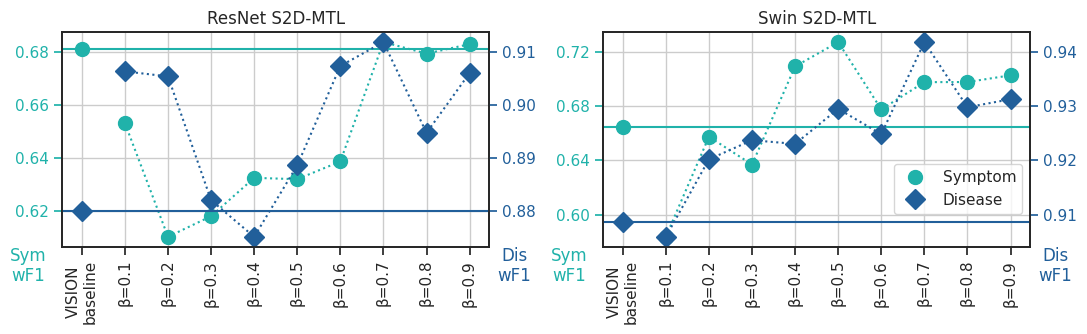

In [9]:
gb = df_s.groupby("backbone")
gb_d = df_d.groupby("backbone")

DIS_COL = "#215f9a"
SYM_COL = "LightSeaGreen"

fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(11,3.5))
idx = -1

for model, group in gb:

    group_d = gb_d.get_group(model)

    if model not in ["resnet", "swint"]:
        continue
    idx+=1
    print(model)
    
    METRIC = "wF1"
    
    ax = axs[idx]
    ax2 = ax.twinx()
    
    baseline = group[(group.kind=="BASE")]
    baseline_points = baseline[METRIC].tolist()
    baseline_x = [0]
    baseline_txt = ["VISION\nbaseline"]
    ax.plot(baseline_x, baseline_points, "o:", ms=10, color=SYM_COL)

    ax.axhline(baseline_points, color=SYM_COL)

    baseline = group_d[(group_d.kind=="BASE")]
    baseline_points = baseline[METRIC].tolist()
    baseline_x = [0]
    baseline_txt = ["VISION\nbaseline"]
    ax2.plot(baseline_x, baseline_points, "D:", ms=10, color=DIS_COL)

    ax2.axhline(baseline_points, color=DIS_COL)


    mtl = group[(group.kind=="S2D-MTL")&(group.alpha==0.5)].sort_values(["alpha", "beta", "gamma"])
    alpha_points = mtl[METRIC].tolist()
    alpha_x = [x*10 for x in mtl.beta]
    ax.plot(alpha_x, alpha_points, "o:", ms=10, color=SYM_COL)

    mtl = group_d[(group_d.kind=="S2D-MTL")&(group_d.alpha==0.5)].sort_values(["alpha", "beta", "gamma"])
    alpha_points = mtl[METRIC].tolist()
    alpha_x = [x*10 for x in mtl.beta]
    ax2.plot(alpha_x, alpha_points, "D:", ms=10, color=DIS_COL)

    alpha_txt = [f"β={x}" for x in mtl.beta]
    txt = baseline_txt+alpha_txt
    ax.set_xticks(range(len(txt)), txt, rotation=90)

    ax.set_title(f"{name2paper[model]} S2D-MTL")
    
    legend_elements = [
        Line2D([0], [0], color=SYM_COL, lw=0, marker="o", ms=10, label="Symptom"),
        Line2D([0], [0], color=DIS_COL, lw=0, marker="D", ms=10, label="Disease"),
        ]

    ax.grid(True)
    # ax2.grid(True)
    # ax.xaxis.grid(True)

    nticks=6

    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))

    l = ax.get_ylim()
    l2 = ax2.get_ylim()
    f = lambda x : l2[0]+(x-l[0])/(l[1]-l[0])*(l2[1]-l2[0])
    ticks = f(ax.get_yticks())
    ax2.yaxis.set_major_locator(mpl.ticker.FixedLocator(ticks))
    ax2.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))

    # ax.set_ylabel("Symptom wF1", color=SYM_COL)
    ax.text(x=-0.08, y=0, s="Sym\nwF1", color=SYM_COL, rotation=0, va="top", ha="center", transform=ax.transAxes)
    ax.tick_params(axis='y', colors=SYM_COL)

    ax2.text(x=1.06, y=0, s="Dis\nwF1", color=DIS_COL, rotation=0, va="top", ha="center", transform=ax2.transAxes)
    ax2.tick_params(axis='y', colors=DIS_COL)

# axs[0].legend(handles=legend_elements, loc='lower right')
axs[1].legend(
    handles=legend_elements,
    bbox_to_anchor=(1, .27),
    loc='center right',
    # borderaxespad=0.,
)

plt.tight_layout()
plt.savefig(f"fig/fig_beta_effect.{OUTPUT_FORMAT}")
plt.show()